# Global Statistics Visualizer

Compute player-focused statistics from enriched Chess.com games and visualize them with radar and component charts.

In [1]:
from dataclasses import asdict, is_dataclass
from pathlib import Path

import chess.engine
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from utils.chesscom_repository import ChessComRepository
from utils.game_enrichment_transformer import GameEnrichmentTransformer
from utils.global_statistics_transformer import GlobalStatisticsTransformer
from utils.opening_repository import OpeningRepository
from utils.player_feature_transformer import (
    PlayerFeatureAggregator,
    PlayerSampleBuilder,
    player_opening_vector,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 160)

In [2]:
USERNAME = "bassisw"
# USERNAME = "MagnusCarlsen"
# USERNAME = "bassisw"
MAX_GAMES = 20
SINCE_YEAR = 2026
SINCE_MONTH = 1

# Choose any subset of: "rapid", "blitz", "bullet".
# Use None to include every time class returned by Chess.com.
TIME_CLASSES = {"rapid"}

# Choose True for rated games, False for unrated games, or None for both.
RATED_FILTER = True

STOCKFISH_PATH = "/opt/homebrew/bin/stockfish"  # Apple Silicon Mac
# STOCKFISH_PATH = "/usr/local/bin/stockfish"   # Intel Mac

OPENINGS_PATH = "openings_dataset/all.tsv"
OPENING_FEATURE_VECTORS_PATH = "openings_dataset/opening_feature_vectors.csv"
GLOBAL_STATISTICS_HPARAMS_PATH = "config/global_statistics_hparams.yaml"
ENGINE_DEPTH = 10

In [3]:
chesscom_repo = ChessComRepository(USERNAME)

def game_matches_filters(game_data: dict) -> bool:
    if TIME_CLASSES is not None and game_data.get("time_class") not in TIME_CLASSES:
        return False

    if RATED_FILTER is not None and game_data.get("rated") is not RATED_FILTER:
        return False

    return True


raw_games = []
seen_games = 0
skipped_games = 0
for game_data in chesscom_repo.iter_all_games(
    since_year=SINCE_YEAR,
    since_month=SINCE_MONTH,
):
    seen_games += 1
    if "pgn" not in game_data:
        skipped_games += 1
        continue

    if not game_matches_filters(game_data):
        skipped_games += 1
        continue

    raw_games.append(game_data)
    if len(raw_games) >= MAX_GAMES:
        break

filter_summary = {
    "username": USERNAME,
    "time_classes": "all" if TIME_CLASSES is None else ", ".join(sorted(TIME_CLASSES)),
    "rated": "both" if RATED_FILTER is None else RATED_FILTER,
    "seen_games": seen_games,
    "skipped_games": skipped_games,
    "selected_games": len(raw_games),
}

display(pd.DataFrame([filter_summary]))
print(f"Selected {len(raw_games)} games after filters")
if not raw_games:
    raise RuntimeError("No games found. Check USERNAME, date range, TIME_CLASSES, and RATED_FILTER.")

,username,time_classes,rated,seen_games,skipped_games,selected_games
0,bassisw,rapid,True,66,46,20


Selected 20 games after filters


In [4]:
opening_repo = OpeningRepository(OPENINGS_PATH)

enrichment_transformer = GameEnrichmentTransformer(
    stockfish_path=STOCKFISH_PATH,
    opening_repository=opening_repo,
    engine_limit=chess.engine.Limit(depth=ENGINE_DEPTH),
)

enriched_games = enrichment_transformer.transform_games(raw_games)
print(f"Enriched {len(enriched_games)} games")

Enriched 20 games


In [5]:
stats = GlobalStatisticsTransformer(GLOBAL_STATISTICS_HPARAMS_PATH).compute(
    enriched_games,
    username=USERNAME,
)

stats

GlobalStatistics(username='bassisw', games_count=20, target_games_count=20, target_moves_count=546, min_samples=3, complexity_p50=130.5398108598871, complexity_p85=159.43802014651496, complexity_p90=197.15750633341625, tactics_score=StatisticResult(score=0.9574634358597213, average_loss=0.042536564140278725, sample_count=217, game_count=18), calculation_score=StatisticResult(score=0.9226220177290521, average_loss=0.07737798227094797, sample_count=63, game_count=11), openings_score=OpeningStatistics(score=0.6414337944265547, book_accuracy=0.16214285714285717, eval_stability_after_opening=0.9579089422365679, result_from_opening_positions=0.39473684210526316, opening_move_count=197, post_opening_move_count=112, game_count=19), middlegame_strategy_score=StatisticResult(score=0.9507537376923317, average_loss=0.049246262307668286, sample_count=102, game_count=16), endgame_score=StatisticResult(score=0.9752090776502216, average_loss=0.024790922349778383, sample_count=173, game_count=7), time_

## Player Style/Skill Vector and Opening Matches

Build the player move samples, aggregate style and skill vectors, and compare the matcher-ready player vector against the precomputed opening feature vectors.

In [6]:
player_samples, castling_summaries = PlayerSampleBuilder().build(
    enriched_games,
    player_name=USERNAME,
)
player_profile = PlayerFeatureAggregator().aggregate(
    player_samples,
    castling_summaries,
    player_name=USERNAME,
)
matcher_ready_player_vector = player_opening_vector(player_profile)

print(
    f"Built player profile from {player_profile.games_analyzed} games "
    f"and {player_profile.moves_analyzed} player moves"
)
player_profile


Built player profile from 20 games and 546 player moves


PlayerProfile(player_name='bassisw', games_analyzed=20, moves_analyzed=546, style_vector={'tactical_exposure': 0.4342857142857143, 'tactical_position_choice': 0.45294117647058824, 'tactical_move_choice': 0.3485714285714286, 'tactical_creation_rate': 0.3979591836734694, 'tactical_defusal_rate': 0.4722222222222222, 'quiet_exposure': 0.6, 'quiet_choice': 0.5764705882352941, 'quiet_creation_rate': 0.48484848484848486, 'complexity_exposure': 0.42264171276114115, 'complexity_choice': 0.45062133813230865, 'complexity_delta': 0.03817496893257077, 'high_complexity_choice_rate': 0.052941176470588235, 'king_safety_risk_tolerance': 0.10884190476190472, 'king_risk_delta': -0.01885686274509804, 'early_castling_tendency': 0.33499999999999996, 'opposite_side_castling_tendency': 0.4, 'queenside_castling_tendency': 0.25, 'pawn_structure_sharpness': 0.3094117647058823, 'material_imbalance_preference': 0.6285714285714286, 'endgame_frequency': 0.4, 'endgame_move_share': 0.31868131868131866, 'opening_divers

In [7]:
def vector_dataframe(vector: dict[str, float | None], confidence: dict[str, float] | None = None) -> pd.DataFrame:
    rows = []
    for feature, value in vector.items():
        rows.append(
            {
                "feature": feature,
                "value": value,
                "confidence": None if confidence is None else confidence.get(feature),
            }
        )
    return pd.DataFrame(rows)


player_profile_summary_df = pd.DataFrame(
    [
        {
            "player_name": player_profile.player_name,
            "games_analyzed": player_profile.games_analyzed,
            "moves_analyzed": player_profile.moves_analyzed,
            "style_features": len(player_profile.style_vector),
            "skill_features": len(player_profile.skill_vector),
        }
    ]
)
player_style_df = vector_dataframe(player_profile.style_vector, player_profile.confidence)
player_skill_df = vector_dataframe(player_profile.skill_vector, player_profile.confidence)
matcher_ready_player_vector_df = pd.DataFrame(
    [
        {"opening_feature": feature, "player_value": value}
        for feature, value in matcher_ready_player_vector.items()
    ]
)

display(player_profile_summary_df)
display(player_style_df)
display(player_skill_df)
display(matcher_ready_player_vector_df)


,player_name,games_analyzed,moves_analyzed,style_features,skill_features
0,bassisw,20,546,25,9


,feature,value,confidence
0,tactical_exposure,0.434286,0.583333
1,tactical_position_choice,0.452941,0.566667
2,tactical_move_choice,0.348571,0.583333
3,tactical_creation_rate,0.397959,0.566667
4,tactical_defusal_rate,0.472222,0.566667
5,quiet_exposure,0.600000,0.583333
6,quiet_choice,0.576471,0.566667
7,quiet_creation_rate,0.484848,0.566667
8,complexity_exposure,0.422642,0.875000
9,complexity_choice,0.450621,0.850000


,feature,value,confidence
0,tactical_performance,0.754075,0.253333
1,quiet_position_performance,0.811837,0.350000
2,complexity_performance,0.742643,0.045000
3,king_safety_performance,NaN,0.000000
4,pawn_structure_comfort,0.829174,1.000000
5,material_imbalance_comfort,0.771145,1.000000
6,endgame_performance,0.676548,1.000000
7,advantage_capitalization,0.780035,1.000000
8,resourcefulness,0.479629,1.000000


,opening_feature,player_value
0,tactical_density,0.452941
1,quiet_position_density,0.576471
2,king_safety_risk,0.108842
3,early_castling_tendency,0.335000
4,opposite_side_castling_tendency,0.400000
5,middlegame_complexity,0.450621
6,pawn_structure_sharpness,0.309412
7,material_imbalance,0.628571
8,endgame_likelihood_proxy,0.400000
9,structure_diversity,0.959848


In [8]:
OPENING_MATCH_TOP_N = 15
OPENING_MATCH_SORT_BY = "cosine_similarity"  # Choose "cosine_similarity" or "dot_product_similarity".
OPENING_MATCH_COLUMNS = list(matcher_ready_player_vector.keys())

opening_features_df = pd.read_csv(OPENING_FEATURE_VECTORS_PATH)
for column in OPENING_MATCH_COLUMNS:
    if column in opening_features_df.columns:
        opening_features_df[column] = pd.to_numeric(opening_features_df[column], errors="coerce")


def comparable_feature_values(row: pd.Series, vector: dict[str, float | None]) -> tuple[list[float], list[float], list[str]]:
    player_values = []
    opening_values = []
    used_features = []
    for feature, player_value in vector.items():
        if player_value is None or pd.isna(player_value):
            continue
        if feature not in row or pd.isna(row[feature]):
            continue
        player_values.append(float(player_value))
        opening_values.append(float(row[feature]))
        used_features.append(feature)
    return player_values, opening_values, used_features


def dot_product_similarity(row: pd.Series, vector: dict[str, float | None]) -> tuple[float, list[str]]:
    player_values, opening_values, used_features = comparable_feature_values(row, vector)
    return sum(a * b for a, b in zip(player_values, opening_values)), used_features


def cosine_similarity(row: pd.Series, vector: dict[str, float | None]) -> tuple[float | None, list[str]]:
    player_values, opening_values, used_features = comparable_feature_values(row, vector)
    player_norm = np.linalg.norm(player_values)
    opening_norm = np.linalg.norm(opening_values)
    if player_norm == 0 or opening_norm == 0:
        return None, used_features
    return float(np.dot(player_values, opening_values) / (player_norm * opening_norm)), used_features


opening_match_rows = []
for _, row in opening_features_df.iterrows():
    dot_similarity, used_features = dot_product_similarity(row, matcher_ready_player_vector)
    cos_similarity, _ = cosine_similarity(row, matcher_ready_player_vector)
    opening_match_rows.append(
        {
            "opening_name": row["opening_name"],
            "eco_values": row.get("eco_values"),
            "line_count": row.get("line_count"),
            "dot_product_similarity": dot_similarity,
            "cosine_similarity": cos_similarity,
            "used_feature_count": len(used_features),
            "used_features": ", ".join(used_features),
            "representative_pgn": row.get("representative_pgn"),
        }
    )

all_opening_matches_df = pd.DataFrame(opening_match_rows)
opening_matches_df = (
    all_opening_matches_df
    .sort_values(OPENING_MATCH_SORT_BY, ascending=False, na_position="last")
    .head(OPENING_MATCH_TOP_N)
    .reset_index(drop=True)
)
opening_matches_dot_df = (
    all_opening_matches_df
    .sort_values("dot_product_similarity", ascending=False, na_position="last")
    .head(OPENING_MATCH_TOP_N)
    .reset_index(drop=True)
)
opening_matches_cosine_df = (
    all_opening_matches_df
    .sort_values("cosine_similarity", ascending=False, na_position="last")
    .head(OPENING_MATCH_TOP_N)
    .reset_index(drop=True)
)

print(f"Primary opening ranking: {OPENING_MATCH_SORT_BY}")
display(opening_matches_df)
print("Top openings by dot product")
display(opening_matches_dot_df)
print("Top openings by cosine similarity")
display(opening_matches_cosine_df)


Primary opening ranking: cosine_similarity


,opening_name,eco_values,line_count,dot_product_similarity,cosine_similarity,used_feature_count,used_features,representative_pgn
0,"French Defense: McCutcheon Variation, Lasker Variation",C12,2,2.033645,0.891926,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e6 2. d4 d5 3. Nc3 Nf6 4. Bg5 Bb4 5. e5 h6 6. Bd2 Bxc3 7. bxc3 Ne4 8. Qg4 g6
1,"Ruy Lopez: Morphy Defense, Steinitz Deferred",C79,2,2.111757,0.891017,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O d6 6. Bxc6+ bxc6 7. d4 Nxe4
2,Italian Game: Two Knights Defense,C55;C58,4,1.984268,0.888424,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bc4 Nf6 4. Ng5 d5 5. exd5 Na5 6. Bb5+ c6 7. dxc6 bxc6 8. Be2
3,"French Defense: Winawer Variation, Poisoned Pawn Variation",C18,3,2.121627,0.882707,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e6 2. d4 d5 3. Nc3 Bb4 4. e5 c5 5. a3 Bxc3+ 6. bxc3 Ne7 7. Qg4 cxd4 8. Qxg7 Rg8 9. Qxh7 Nbc6
4,Queen's Gambit Declined: Harrwitz Attack,D35;D37,4,1.597470,0.872989,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. Nc3 Be7 5. Bf4 O-O 6. e3 c5 7. dxc5 Bxc5 8. Qc2 Nc6 9. Rd1 Qa5 10. a3
5,"Sicilian Defense: Lasker-Pelikan Variation, Sveshnikov Variation",B33,2,2.006974,0.872779,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 c5 2. Nf3 Nc6 3. d4 cxd4 4. Nxd4 Nf6 5. Nc3 e5 6. Ndb5 d6 7. Bg5 a6 8. Na3 b5 9. Bxf6 gxf6 10. Nd5 f5
6,"English Opening: King's English Variation, Four Knights Variation",A28,2,1.936887,0.869068,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. c4 e5 2. Nc3 Nf6 3. Nf3 Nc6 4. d4 exd4 5. Nxd4 Bb4 6. Bg5 h6 7. Bh4 Bxc3+ 8. bxc3 Ne5
7,"King's Gambit Accepted: Cunningham Defense, Bertin Gambit",C35,2,1.935229,0.868585,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. f4 exf4 3. Nf3 Be7 4. Bc4 Bh4+ 5. g3 fxg3 6. O-O gxh2+ 7. Kh1
8,Grünfeld Defense: Russian Variation,D96;D97,2,1.973276,0.868021,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 Nf6 2. c4 g6 3. Nc3 d5 4. Nf3 Bg7 5. Qb3 dxc4 6. Qxc4 O-O 7. e4
9,"Ruy Lopez: Berlin Defense, Rio de Janeiro Variation",C67,2,2.134591,0.862740,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. d4 Be7 6. Qe2 Nd6 7. Bxc6 bxc6 8. dxe5 Nb7 9. Nc3 O-O 10. Re1 Nc5 11. Nd4 Ne6 12. Be3 Nxd4 13. Bxd4 c5


Top openings by dot product


,opening_name,eco_values,line_count,dot_product_similarity,cosine_similarity,used_feature_count,used_features,representative_pgn
0,"Nimzo-Indian Defense: Normal Variation, Gligoric System, Bernstein Defense",E56;E57,2,2.222123,0.804599,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 Nf6 2. c4 e6 3. Nc3 Bb4 4. e3 O-O 5. Bd3 d5 6. Nf3 c5 7. O-O Nc6 8. a3 dxc4 9. Bxc4 cxd4
1,"Ruy Lopez: Berlin Defense, Rio de Janeiro Variation",C67,2,2.134591,0.862740,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. d4 Be7 6. Qe2 Nd6 7. Bxc6 bxc6 8. dxe5 Nb7 9. Nc3 O-O 10. Re1 Nc5 11. Nd4 Ne6 12. Be3 Nxd4 13. Bxd4 c5
2,"French Defense: Winawer Variation, Poisoned Pawn Variation",C18,3,2.121627,0.882707,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e6 2. d4 d5 3. Nc3 Bb4 4. e5 c5 5. a3 Bxc3+ 6. bxc3 Ne7 7. Qg4 cxd4 8. Qxg7 Rg8 9. Qxh7 Nbc6
3,"Ruy Lopez: Morphy Defense, Steinitz Deferred",C79,2,2.111757,0.891017,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O d6 6. Bxc6+ bxc6 7. d4 Nxe4
4,King's Indian Defense: Steiner Attack,E81,4,2.098221,0.821081,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. f3 O-O 6. Bg5 c5 7. d5 e6 8. Qd2 exd5 9. Nxd5
5,"Benoni Defense: King's Pawn Line, with Bg5",A65,3,2.076751,0.836736,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. f3 O-O 6. Bg5 c5 7. d5 e6 8. Qd2 exd5 9. exd5
6,Italian Game: Evans Gambit,C51;C52,3,2.043148,0.859644,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bc4 Bc5 4. b4 Bxb4 5. c3 Bc5 6. d4 exd4 7. O-O d6 8. cxd4 Bb6 9. Nc3 Bg4
7,"French Defense: McCutcheon Variation, Lasker Variation",C12,2,2.033645,0.891926,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e6 2. d4 d5 3. Nc3 Nf6 4. Bg5 Bb4 5. e5 h6 6. Bd2 Bxc3 7. bxc3 Ne4 8. Qg4 g6
8,Queen's Gambit Declined: Tartakower Defense,D58;D59,2,2.033188,0.858282,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 d5 2. c4 e6 3. Nc3 Be7 4. Nf3 Nf6 5. Bg5 h6 6. Bh4 O-O 7. e3 b6 8. cxd5 Nxd5 9. Bxe7 Qxe7 10. Nxd5 exd5 11. Rc1 Be6
9,King's Indian Defense: Sämisch Variation,E80;E86,2,2.013743,0.798456,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 Nf6 2. c4 g6 3. Nc3 Bg7 4. e4 d6 5. f3 O-O 6. Be3 e5 7. Nge2 c6


Top openings by cosine similarity


,opening_name,eco_values,line_count,dot_product_similarity,cosine_similarity,used_feature_count,used_features,representative_pgn
0,"French Defense: McCutcheon Variation, Lasker Variation",C12,2,2.033645,0.891926,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e6 2. d4 d5 3. Nc3 Nf6 4. Bg5 Bb4 5. e5 h6 6. Bd2 Bxc3 7. bxc3 Ne4 8. Qg4 g6
1,"Ruy Lopez: Morphy Defense, Steinitz Deferred",C79,2,2.111757,0.891017,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bb5 a6 4. Ba4 Nf6 5. O-O d6 6. Bxc6+ bxc6 7. d4 Nxe4
2,Italian Game: Two Knights Defense,C55;C58,4,1.984268,0.888424,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bc4 Nf6 4. Ng5 d5 5. exd5 Na5 6. Bb5+ c6 7. dxc6 bxc6 8. Be2
3,"French Defense: Winawer Variation, Poisoned Pawn Variation",C18,3,2.121627,0.882707,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e6 2. d4 d5 3. Nc3 Bb4 4. e5 c5 5. a3 Bxc3+ 6. bxc3 Ne7 7. Qg4 cxd4 8. Qxg7 Rg8 9. Qxh7 Nbc6
4,Queen's Gambit Declined: Harrwitz Attack,D35;D37,4,1.597470,0.872989,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 Nf6 2. c4 e6 3. Nf3 d5 4. Nc3 Be7 5. Bf4 O-O 6. e3 c5 7. dxc5 Bxc5 8. Qc2 Nc6 9. Rd1 Qa5 10. a3
5,"Sicilian Defense: Lasker-Pelikan Variation, Sveshnikov Variation",B33,2,2.006974,0.872779,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 c5 2. Nf3 Nc6 3. d4 cxd4 4. Nxd4 Nf6 5. Nc3 e5 6. Ndb5 d6 7. Bg5 a6 8. Na3 b5 9. Bxf6 gxf6 10. Nd5 f5
6,"English Opening: King's English Variation, Four Knights Variation",A28,2,1.936887,0.869068,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. c4 e5 2. Nc3 Nf6 3. Nf3 Nc6 4. d4 exd4 5. Nxd4 Bb4 6. Bg5 h6 7. Bh4 Bxc3+ 8. bxc3 Ne5
7,"King's Gambit Accepted: Cunningham Defense, Bertin Gambit",C35,2,1.935229,0.868585,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. f4 exf4 3. Nf3 Be7 4. Bc4 Bh4+ 5. g3 fxg3 6. O-O gxh2+ 7. Kh1
8,Grünfeld Defense: Russian Variation,D96;D97,2,1.973276,0.868021,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. d4 Nf6 2. c4 g6 3. Nc3 d5 4. Nf3 Bg7 5. Qb3 dxc4 6. Qxc4 O-O 7. e4
9,"Ruy Lopez: Berlin Defense, Rio de Janeiro Variation",C67,2,2.134591,0.862740,10,"tactical_density, quiet_position_density, king_safety_risk, early_castling_tendency, opposite_side_castling_tendency, middlegame_complexity, pawn_structure_...",1. e4 e5 2. Nf3 Nc6 3. Bb5 Nf6 4. O-O Nxe4 5. d4 Be7 6. Qe2 Nd6 7. Bxc6 bxc6 8. dxe5 Nb7 9. Nc3 O-O 10. Re1 Nc5 11. Nd4 Ne6 12. Be3 Nxd4 13. Bxd4 c5


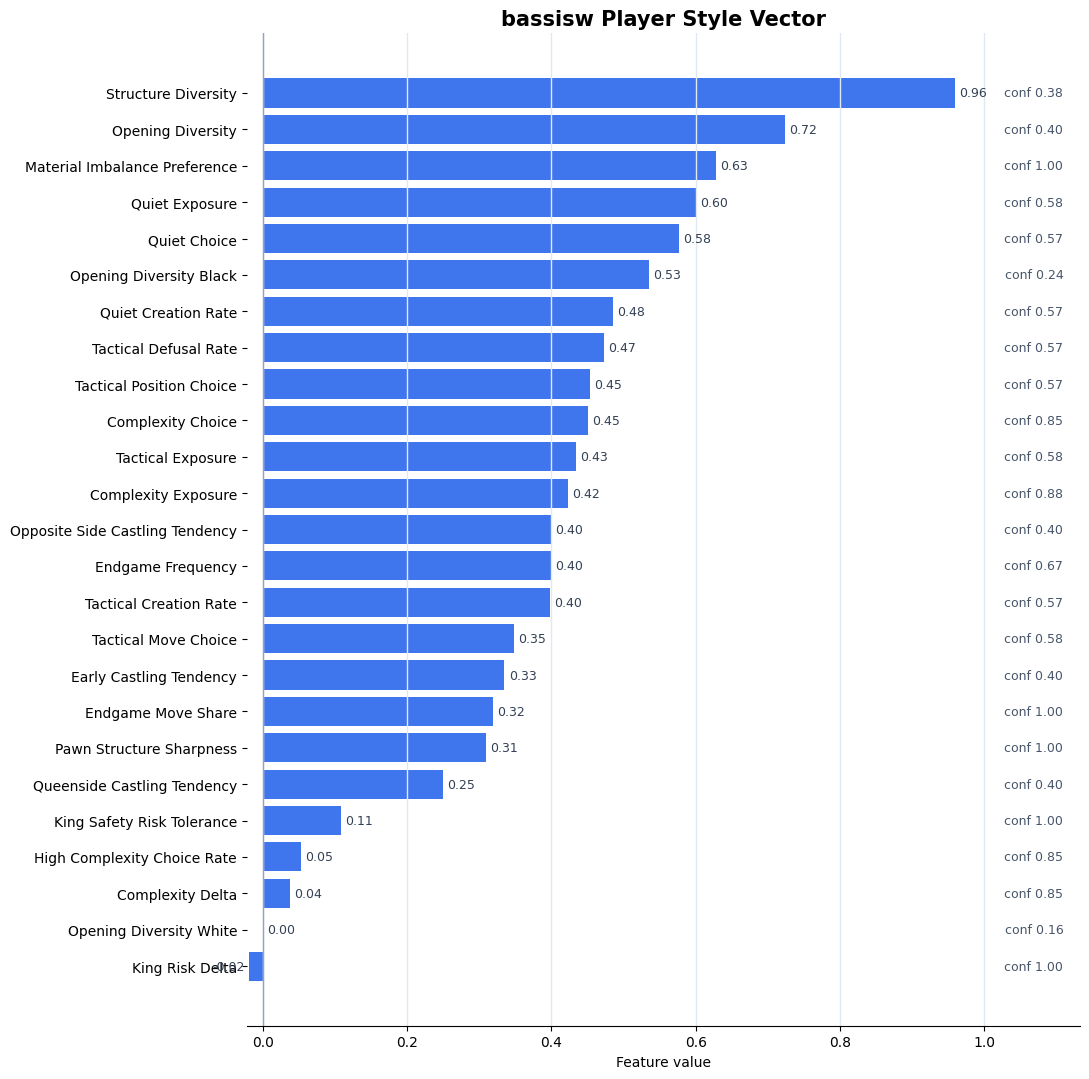

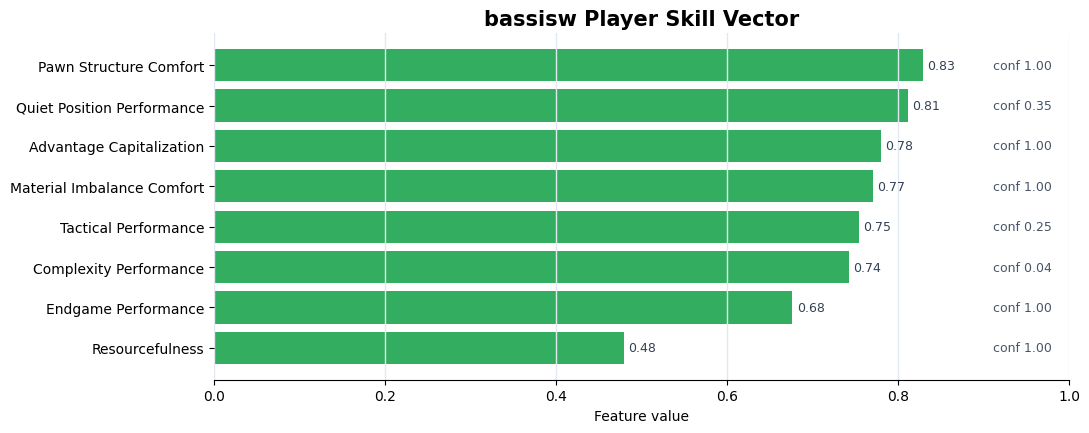

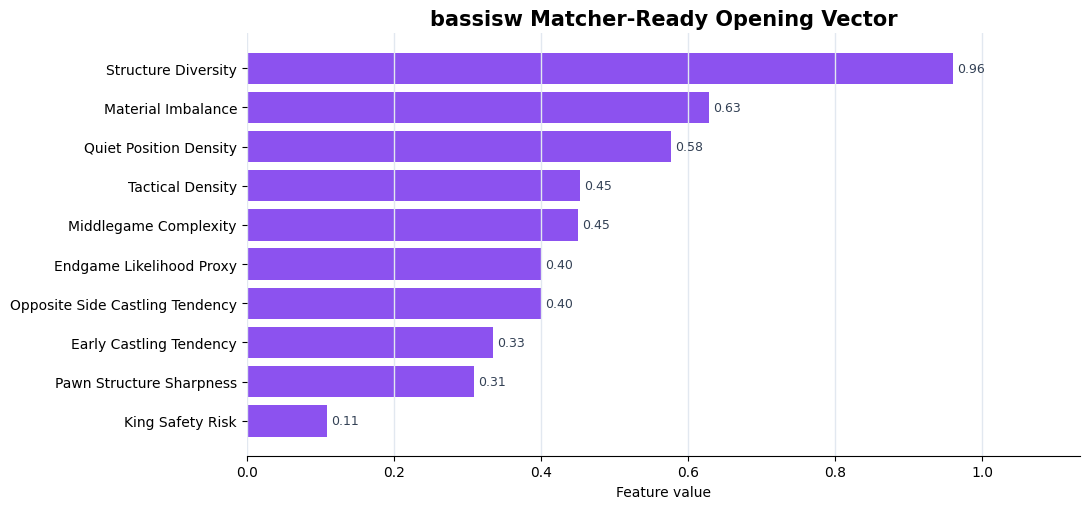

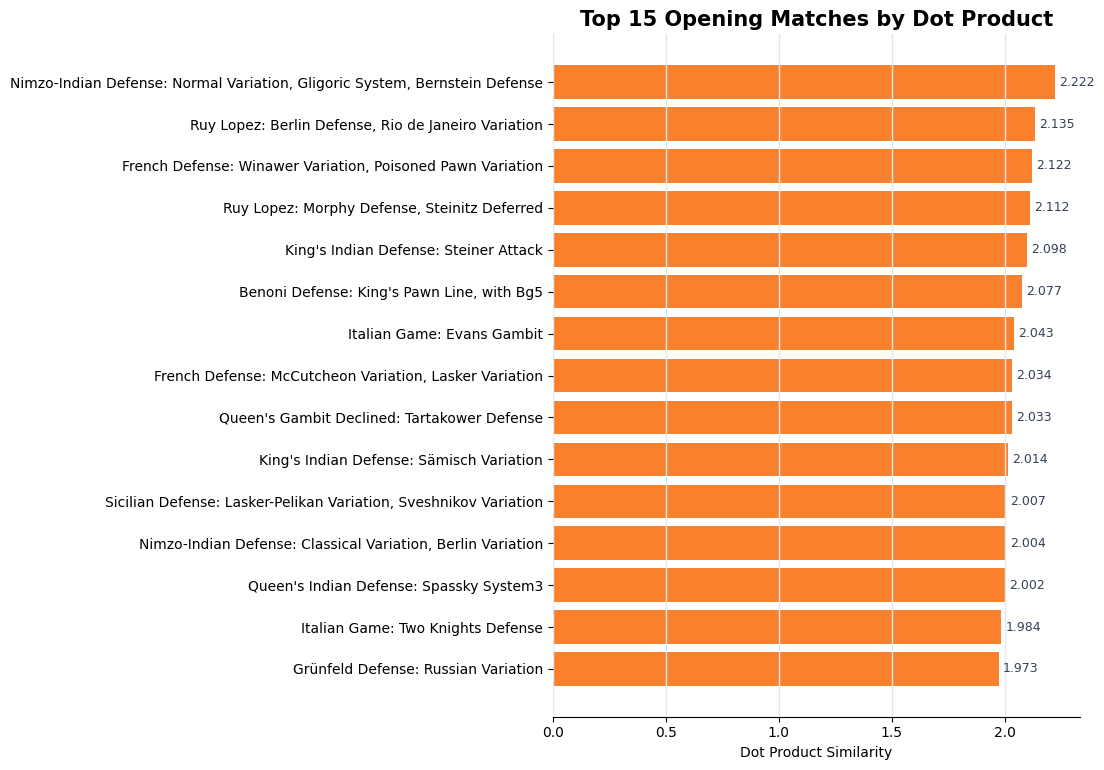

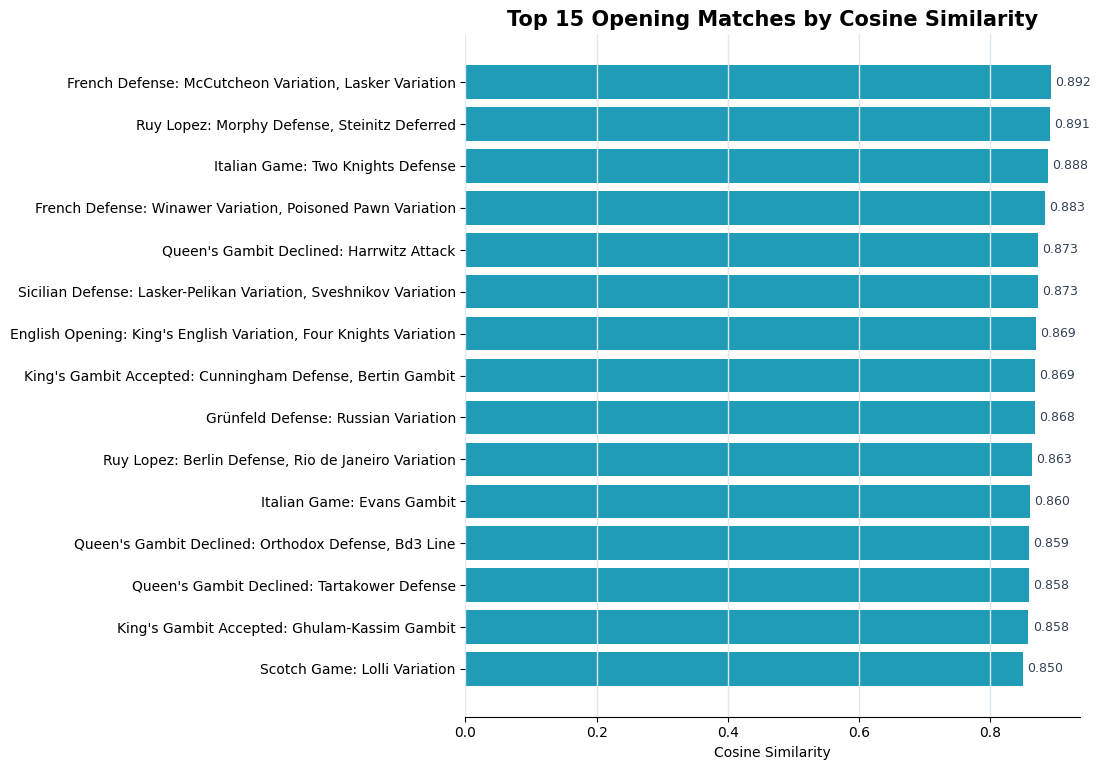

In [9]:
def pretty_feature_name(value: str) -> str:
    return value.replace("_", " ").title()


def plot_feature_barh(
    df: pd.DataFrame,
    *,
    title: str,
    feature_column: str = "feature",
    value_column: str = "value",
    confidence_column: str | None = "confidence",
    color: str = "#2563eb",
    sort_values: bool = True,
):
    plot_df = df.copy()
    plot_df = plot_df[plot_df[value_column].notna()].copy()
    if plot_df.empty:
        print(f"No values available for {title}")
        return
    if sort_values:
        plot_df = plot_df.sort_values(value_column, ascending=True)

    height = max(4.0, 0.38 * len(plot_df) + 1.4)
    fig, ax = plt.subplots(figsize=(11, height))
    labels = [pretty_feature_name(value) for value in plot_df[feature_column]]
    bars = ax.barh(labels, plot_df[value_column], color=color, alpha=0.88)
    min_value = float(plot_df[value_column].min())
    max_value = float(plot_df[value_column].max())
    left_limit = min(0.0, min_value * 1.18)
    right_limit = max(1.0, max_value * 1.18)
    span = right_limit - left_limit

    if confidence_column and confidence_column in plot_df.columns:
        for bar, confidence in zip(bars, plot_df[confidence_column]):
            if pd.isna(confidence):
                continue
            ax.text(
                right_limit - 0.02 * span,
                bar.get_y() + bar.get_height() / 2,
                f"conf {confidence:.2f}",
                va="center",
                ha="right",
                fontsize=9,
                color="#475569",
            )

    ax.set_xlim(left_limit, right_limit)
    if left_limit < 0:
        ax.axvline(0, color="#94a3b8", linewidth=1)
    ax.set_xlabel("Feature value")
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.grid(axis="x", color="#e2e8f0", linewidth=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color="#334155")
    plt.tight_layout()
    plt.show()


plot_feature_barh(
    player_style_df,
    title=f"{USERNAME} Player Style Vector",
    color="#2563eb",
)
plot_feature_barh(
    player_skill_df,
    title=f"{USERNAME} Player Skill Vector",
    color="#16a34a",
)
plot_feature_barh(
    matcher_ready_player_vector_df.rename(
        columns={"opening_feature": "feature", "player_value": "value"}
    ),
    title=f"{USERNAME} Matcher-Ready Opening Vector",
    confidence_column=None,
    color="#7c3aed",
)

def plot_opening_similarity_rank(df: pd.DataFrame, metric: str, *, title: str, color: str):
    plot_df = df.sort_values(metric, ascending=True).copy()
    fig, ax = plt.subplots(figsize=(11, max(4, 0.42 * len(plot_df) + 1.5)))
    bars = ax.barh(
        plot_df["opening_name"],
        plot_df[metric],
        color=color,
        alpha=0.9,
    )
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel(metric.replace("_", " ").title())
    ax.grid(axis="x", color="#e2e8f0", linewidth=1)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=9, color="#334155")
    plt.tight_layout()
    plt.show()


plot_opening_similarity_rank(
    opening_matches_dot_df,
    "dot_product_similarity",
    title=f"Top {len(opening_matches_dot_df)} Opening Matches by Dot Product",
    color="#f97316",
)
plot_opening_similarity_rank(
    opening_matches_cosine_df,
    "cosine_similarity",
    title=f"Top {len(opening_matches_cosine_df)} Opening Matches by Cosine Similarity",
    color="#0891b2",
)


,opening_name,opening_feature,player_value,opening_value,dot_product_similarity,cosine_similarity
0,"French Defense: McCutcheon Variation, Lasker Variation",tactical_density,0.452941,0.466063,2.033645,0.891926
1,"French Defense: McCutcheon Variation, Lasker Variation",quiet_position_density,0.576471,0.504525,2.033645,0.891926
2,"French Defense: McCutcheon Variation, Lasker Variation",king_safety_risk,0.108842,0.022500,2.033645,0.891926
3,"French Defense: McCutcheon Variation, Lasker Variation",early_castling_tendency,0.335000,0.000000,2.033645,0.891926
4,"French Defense: McCutcheon Variation, Lasker Variation",opposite_side_castling_tendency,0.400000,0.000000,2.033645,0.891926
...,...,...,...,...,...,...
75,"King's Gambit Accepted: Cunningham Defense, Bertin Gambit",middlegame_complexity,0.450621,0.219629,1.935229,0.868585
76,"King's Gambit Accepted: Cunningham Defense, Bertin Gambit",pawn_structure_sharpness,0.309412,0.296875,1.935229,0.868585
77,"King's Gambit Accepted: Cunningham Defense, Bertin Gambit",material_imbalance,0.628571,0.000000,1.935229,0.868585
78,"King's Gambit Accepted: Cunningham Defense, Bertin Gambit",endgame_likelihood_proxy,0.400000,0.437248,1.935229,0.868585


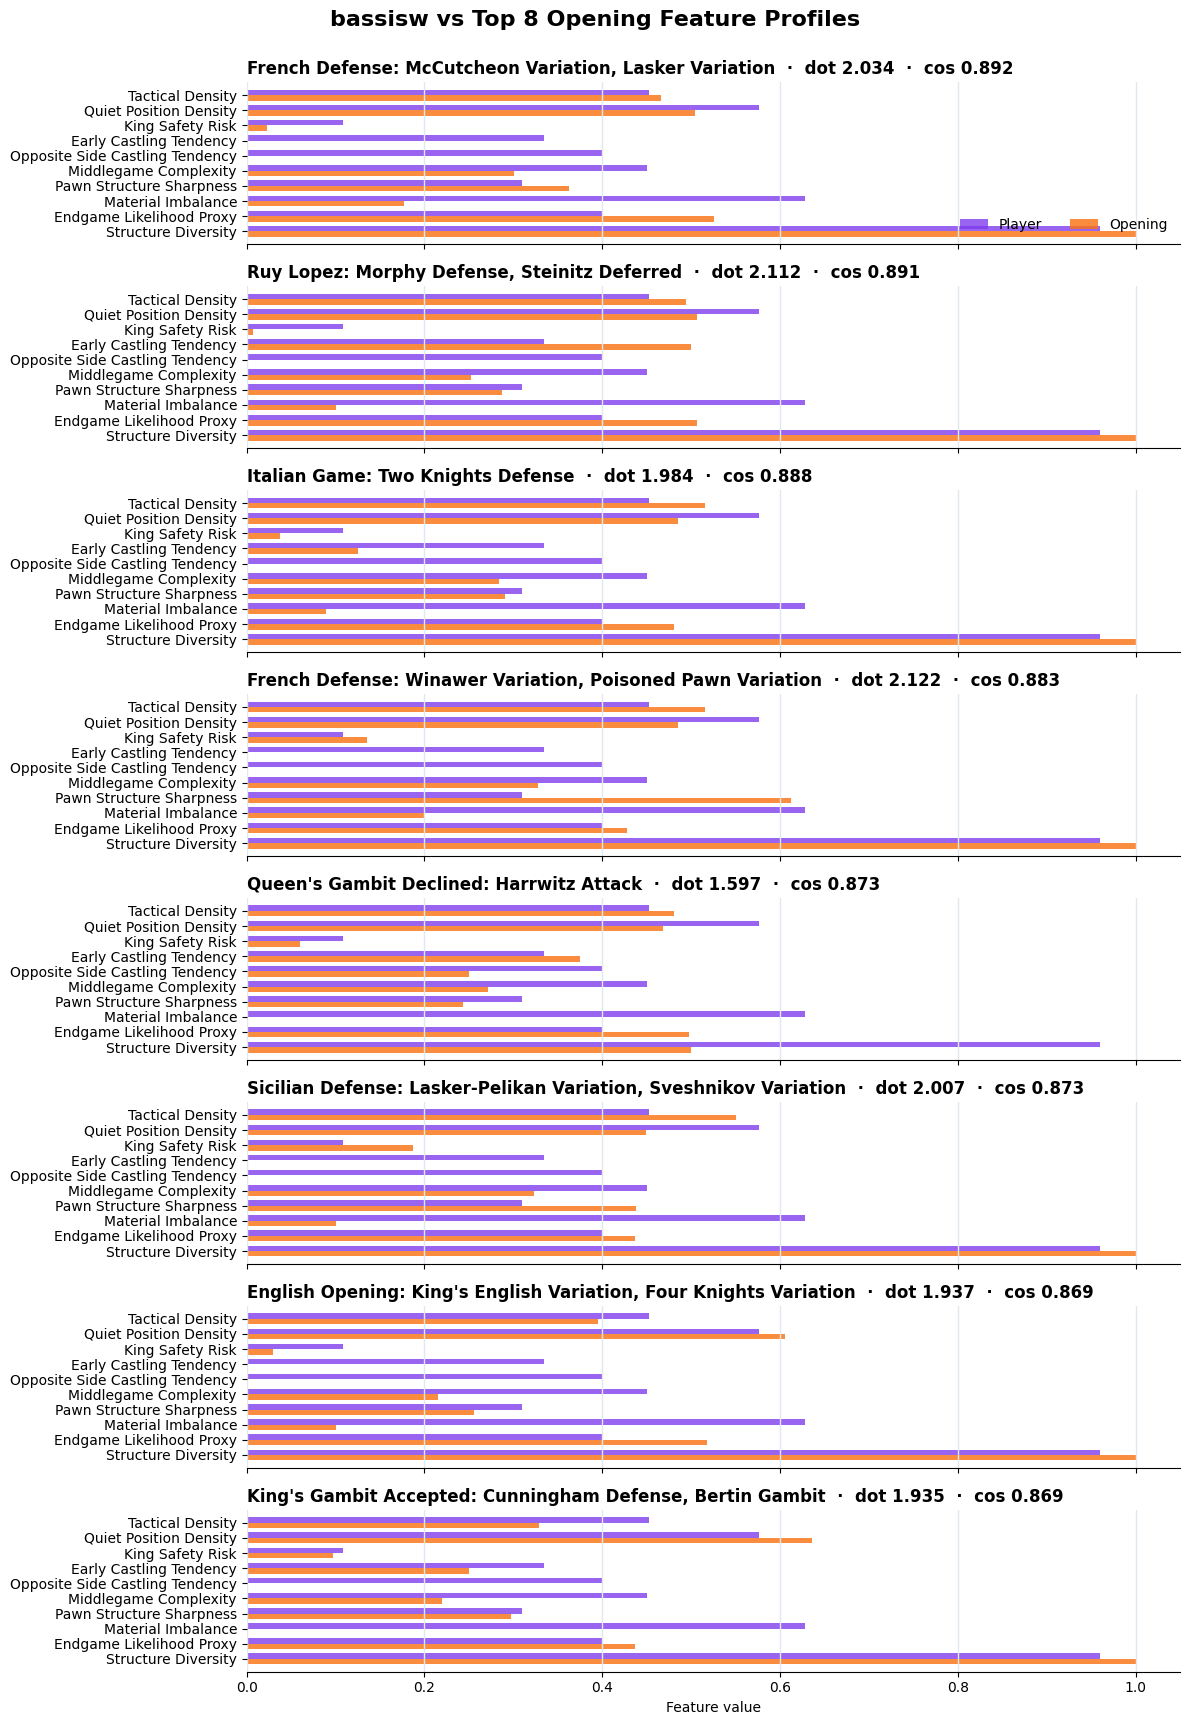

In [10]:
OPENING_FEATURE_PLOT_TOP_K = min(8, len(opening_matches_df))
matched_openings_to_plot = opening_matches_df.head(OPENING_FEATURE_PLOT_TOP_K)
matcher_features = [
    feature for feature, value in matcher_ready_player_vector.items()
    if value is not None and not pd.isna(value)
]

matched_opening_feature_rows = []
for _, match in matched_openings_to_plot.iterrows():
    opening_row = opening_features_df.loc[
        opening_features_df["opening_name"] == match["opening_name"]
    ].iloc[0]
    for feature in matcher_features:
        matched_opening_feature_rows.append(
            {
                "opening_name": match["opening_name"],
                "opening_feature": feature,
                "player_value": matcher_ready_player_vector[feature],
                "opening_value": opening_row.get(feature),
                "dot_product_similarity": match["dot_product_similarity"],
                "cosine_similarity": match["cosine_similarity"],
            }
        )

matched_opening_features_df = pd.DataFrame(matched_opening_feature_rows)
matched_opening_features_df["opening_value"] = pd.to_numeric(
    matched_opening_features_df["opening_value"], errors="coerce"
)
display(matched_opening_features_df)

if matched_opening_features_df.empty:
    print("No matched opening features available to plot.")
else:
    fig, axes = plt.subplots(
        nrows=len(matched_openings_to_plot),
        ncols=1,
        figsize=(12, max(4, 2.15 * len(matched_openings_to_plot))),
        sharex=True,
    )
    if len(matched_openings_to_plot) == 1:
        axes = [axes]

    feature_labels = [pretty_feature_name(feature) for feature in matcher_features]
    y = np.arange(len(matcher_features))
    bar_height = 0.36

    for ax, (_, match) in zip(axes, matched_openings_to_plot.iterrows()):
        plot_df = matched_opening_features_df[
            matched_opening_features_df["opening_name"] == match["opening_name"]
        ].set_index("opening_feature").reindex(matcher_features)
        player_values = plot_df["player_value"].astype(float).fillna(0.0).to_numpy()
        opening_values = plot_df["opening_value"].astype(float).fillna(0.0).to_numpy()

        ax.barh(
            y - bar_height / 2,
            player_values,
            height=bar_height,
            color="#7c3aed",
            alpha=0.78,
            label="Player",
        )
        ax.barh(
            y + bar_height / 2,
            opening_values,
            height=bar_height,
            color="#f97316",
            alpha=0.82,
            label="Opening",
        )
        ax.set_yticks(y)
        ax.set_yticklabels(feature_labels)
        ax.invert_yaxis()
        ax.set_title(
            f"{match['opening_name']}  ·  dot {match['dot_product_similarity']:.3f}  ·  cos {match['cosine_similarity']:.3f}",
            fontsize=12,
            fontweight="bold",
            loc="left",
        )
        ax.grid(axis="x", color="#e2e8f0", linewidth=1)
        ax.spines[["top", "right", "left"]].set_visible(False)
        ax.set_xlim(0, 1.05)

    axes[0].legend(loc="lower right", frameon=False, ncols=2)
    axes[-1].set_xlabel("Feature value")
    fig.suptitle(
        f"{USERNAME} vs Top {OPENING_FEATURE_PLOT_TOP_K} Opening Feature Profiles",
        fontsize=16,
        fontweight="bold",
        y=1.0,
    )
    plt.tight_layout()
    plt.show()


In [11]:
def score_value(section):
    return None if section is None else section.score


skill_scores = {
    "Tactics": score_value(stats.tactics_score),
    "Calculation": score_value(stats.calculation_score),
    "Openings": score_value(stats.openings_score),
    "Middlegame Strategy": score_value(stats.middlegame_strategy_score),
    "Endgame": score_value(stats.endgame_score),
    "Time Management": score_value(stats.time_management_score),
    "Game Analysis": score_value(stats.game_analysis_score),
    "Advantage Capitalization": score_value(stats.advantage_capitalization_score),
    "Resourcefulness": score_value(stats.resourcefulness_score),
}

skill_scores_df = pd.DataFrame(
    [
        {"skill": skill, "score": score, "score_pct": None if score is None else score * 100}
        for skill, score in skill_scores.items()
    ]
)

display(skill_scores_df)

,skill,score,score_pct
0,Tactics,0.957463,95.746344
1,Calculation,0.922622,92.262202
2,Openings,0.641434,64.143379
3,Middlegame Strategy,0.950754,95.075374
4,Endgame,0.975209,97.520908
5,Time Management,0.839224,83.922426
6,Game Analysis,0.833333,83.333333
7,Advantage Capitalization,0.716678,71.667828
8,Resourcefulness,0.443774,44.377371


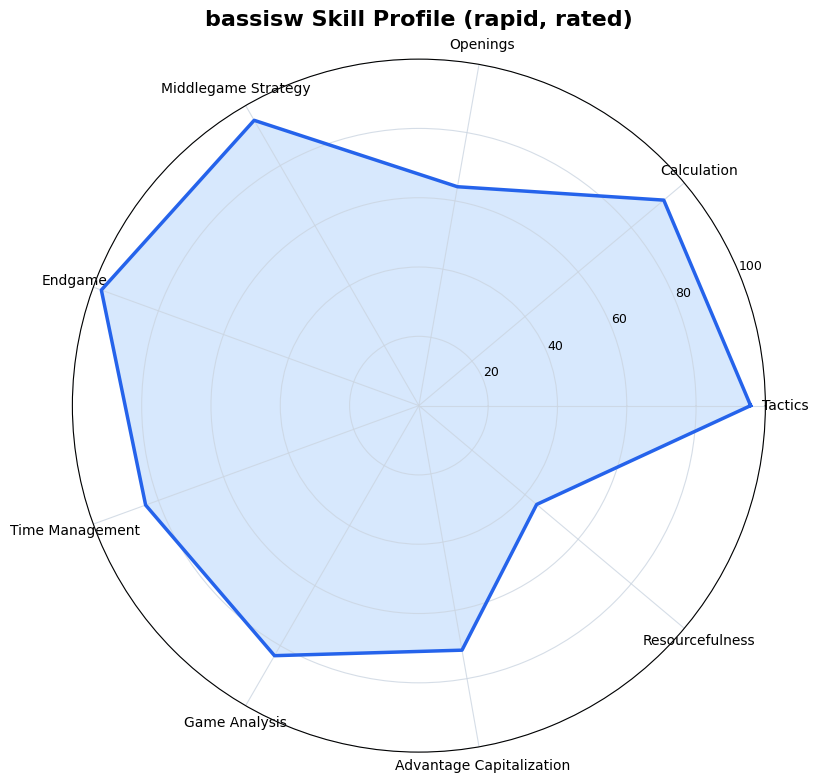

In [12]:
def plot_radar_chart(scores: dict[str, float | None], title: str):
    labels = list(scores.keys())
    values = [0.0 if value is None else float(value) for value in scores.values()]
    missing = [label for label, value in scores.items() if value is None]

    angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
    values_closed = values + values[:1]
    angles_closed = angles + angles[:1]

    fig, ax = plt.subplots(figsize=(9, 9), subplot_kw={"polar": True})
    ax.plot(angles_closed, values_closed, linewidth=2.5, color="#2563eb")
    ax.fill(angles_closed, values_closed, color="#60a5fa", alpha=0.25)

    ax.set_xticks(angles)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylim(0, 1)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["20", "40", "60", "80", "100"], fontsize=9)
    ax.set_title(title, pad=24, fontsize=16, fontweight="bold")
    ax.grid(color="#cbd5e1", alpha=0.8)

    if missing:
        fig.text(
            0.5,
            0.02,
            "Missing sample threshold: " + ", ".join(missing),
            ha="center",
            fontsize=9,
            color="#64748b",
        )

    plt.show()


time_class_label = "all time classes" if TIME_CLASSES is None else ", ".join(sorted(TIME_CLASSES))
rated_label = "rated + unrated" if RATED_FILTER is None else ("rated" if RATED_FILTER else "unrated")

plot_radar_chart(skill_scores, f"{USERNAME} Skill Profile ({time_class_label}, {rated_label})")

In [13]:
def dataclass_to_flat_dict(value, prefix=""):
    if is_dataclass(value):
        value = asdict(value)

    flat = {}
    for key, item in value.items():
        name = f"{prefix}.{key}" if prefix else key
        if isinstance(item, dict):
            flat.update(dataclass_to_flat_dict(item, name))
        else:
            flat[name] = item
    return flat


details = dataclass_to_flat_dict(stats)
details_df = pd.DataFrame(
    [{"metric": metric, "value": value} for metric, value in details.items()]
)

display(details_df)

,metric,value
0,username,bassisw
1,games_count,20
2,target_games_count,20
3,target_moves_count,546
4,min_samples,3
...,...,...
66,resourcefulness_score.survival_moves_before_collapse,8.833333
67,resourcefulness_score.low_collapse_rate_when_worse,0.921875
68,resourcefulness_score.worse_game_count,12
69,resourcefulness_score.lost_game_count,6


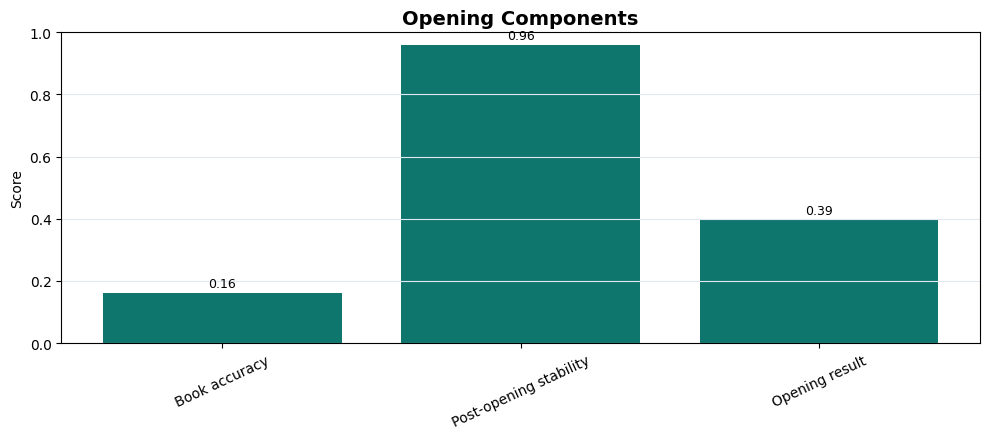

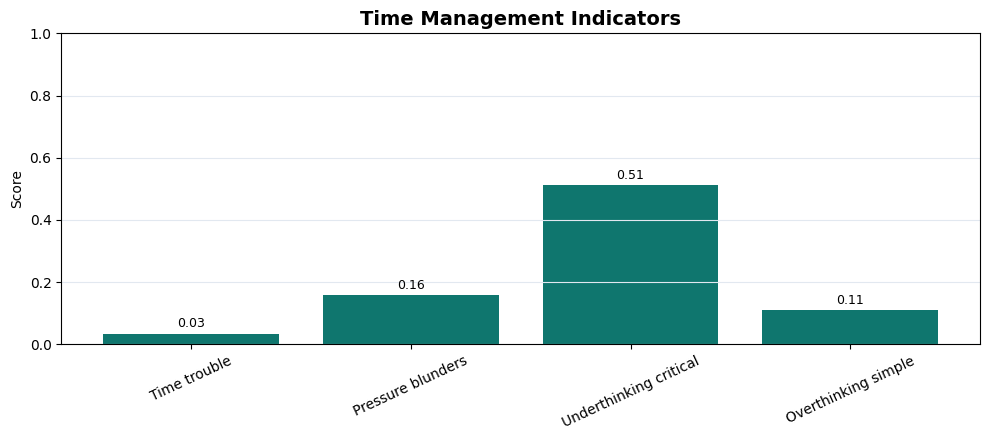

In [14]:
def plot_component_bar(title: str, components: dict[str, float | None], *, as_percent: bool = True):
    labels = list(components.keys())
    values = [0.0 if value is None else float(value) for value in components.values()]
    colors = ["#94a3b8" if value is None else "#0f766e" for value in components.values()]

    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(labels, values, color=colors)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.set_ylim(0, 1 if as_percent else max(values + [1]))
    ax.set_ylabel("Score" if as_percent else "Value")
    ax.tick_params(axis="x", labelrotation=25)
    ax.grid(axis="y", color="#e2e8f0")

    for index, value in enumerate(values):
        label = "n/a" if list(components.values())[index] is None else f"{value:.2f}"
        ax.text(index, value + 0.02, label, ha="center", fontsize=9)

    plt.tight_layout()
    plt.show()


plot_component_bar(
    "Opening Components",
    {
        "Book accuracy": stats.openings_score.book_accuracy,
        "Post-opening stability": stats.openings_score.eval_stability_after_opening,
        "Opening result": stats.openings_score.result_from_opening_positions,
    },
)

plot_component_bar(
    "Time Management Indicators",
    {
        "Time trouble": stats.time_management_score.time_trouble_frequency,
        "Pressure blunders": stats.time_management_score.blunder_rate_in_time_pressure,
        "Underthinking critical": stats.time_management_score.critical_position_underthinking_rate,
        "Overthinking simple": stats.time_management_score.overthinking_simple_positions_rate,
    },
)

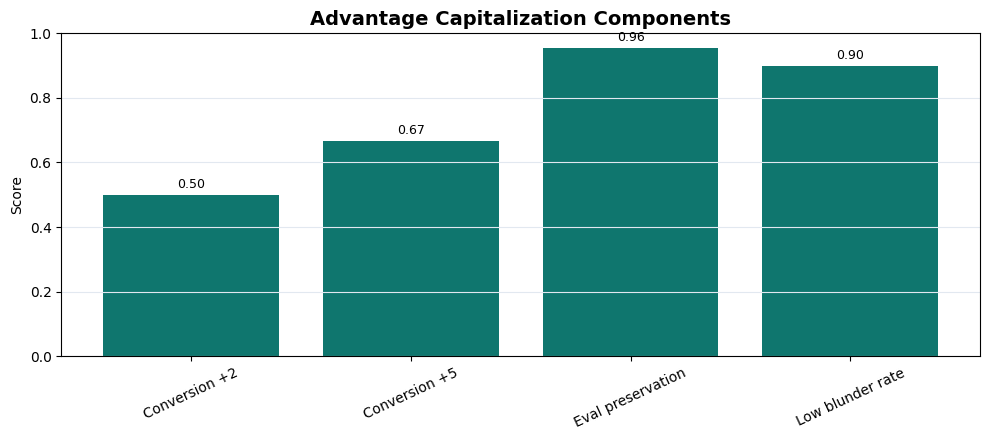

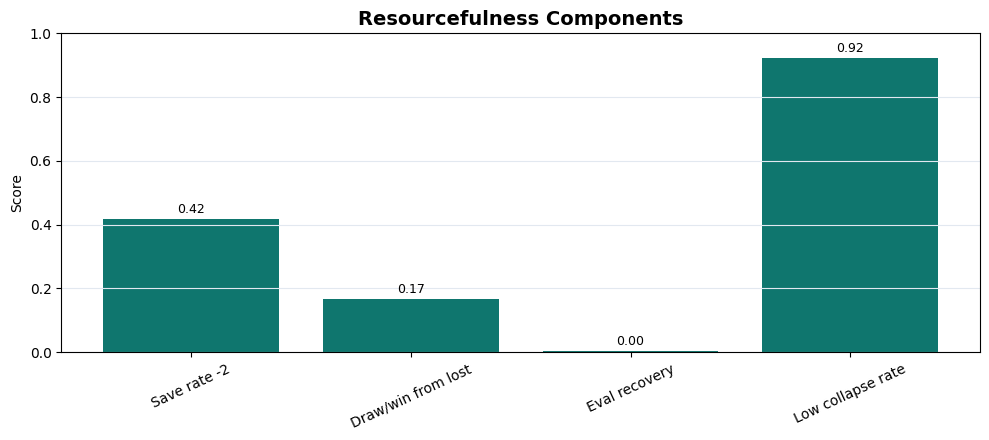

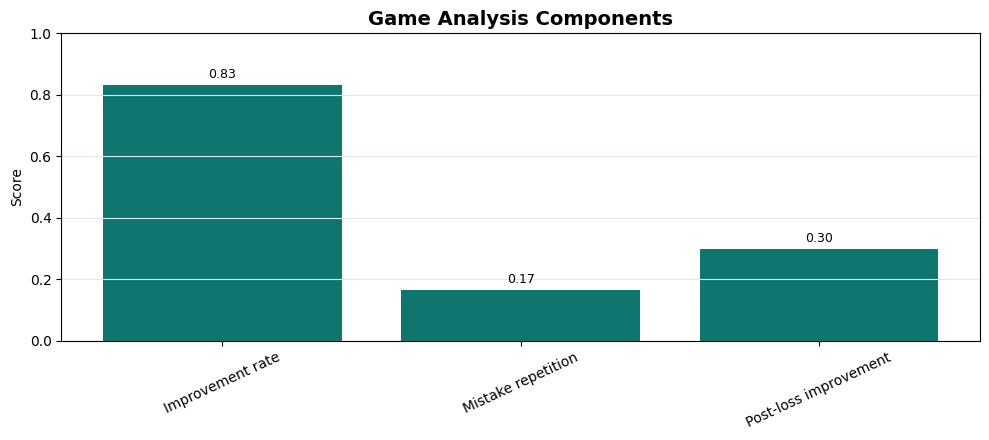

In [15]:
plot_component_bar(
    "Advantage Capitalization Components",
    {
        "Conversion +2": stats.advantage_capitalization_score.conversion_rate_from_plus_2,
        "Conversion +5": stats.advantage_capitalization_score.conversion_rate_from_plus_5,
        "Eval preservation": stats.advantage_capitalization_score.eval_preservation_when_ahead,
        "Low blunder rate": stats.advantage_capitalization_score.low_blunder_rate_when_ahead,
    },
)

plot_component_bar(
    "Resourcefulness Components",
    {
        "Save rate -2": stats.resourcefulness_score.save_rate_from_minus_2,
        "Draw/win from lost": stats.resourcefulness_score.draw_or_win_rate_from_lost_positions,
        "Eval recovery": stats.resourcefulness_score.eval_recovery_rate,
        "Low collapse rate": stats.resourcefulness_score.low_collapse_rate_when_worse,
    },
)

plot_component_bar(
    "Game Analysis Components",
    {
        "Improvement rate": stats.game_analysis_score.weakness_improvement_rate,
        "Mistake repetition": stats.game_analysis_score.mistake_repetition_rate,
        "Post-loss improvement": stats.game_analysis_score.post_loss_improvement,
    },
)

,complexity_bucket,average_seconds
0,simple,9.305818
1,normal,15.221320
2,complex,17.409091
3,high_complexity,5.294231


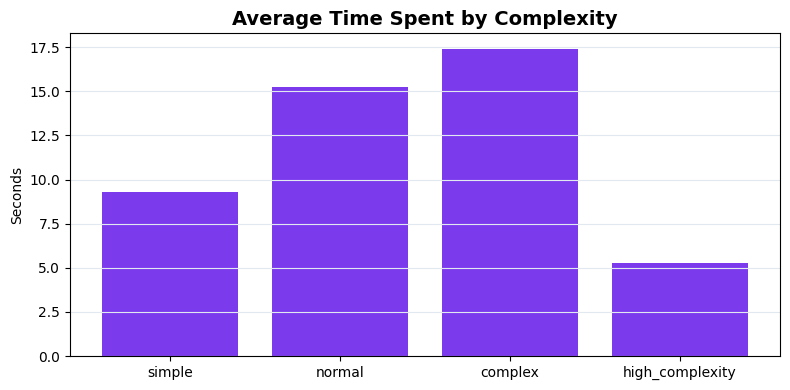

In [16]:
time_by_complexity = stats.time_management_score.average_time_spent_by_complexity
time_by_complexity_df = pd.DataFrame(
    [
        {"complexity_bucket": bucket, "average_seconds": value}
        for bucket, value in time_by_complexity.items()
    ]
)

display(time_by_complexity_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    time_by_complexity_df["complexity_bucket"],
    time_by_complexity_df["average_seconds"].fillna(0),
    color="#7c3aed",
)
ax.set_title("Average Time Spent by Complexity", fontsize=14, fontweight="bold")
ax.set_ylabel("Seconds")
ax.grid(axis="y", color="#e2e8f0")
plt.tight_layout()
plt.show()